In [1]:
import numpy as np
import pandas as pd
from numba import jit

import matplotlib
matplotlib.rcParams['image.cmap'] = 'jet'
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from sklearn.metrics import roc_auc_score

Gradient Descent:
$$
L = \frac{1}{N}\sum_{a=1}^{N} (s_{u_{a} i_{a}} - \langle p_a, q_a \rangle)^2
$$

$$
L = \frac{1}{batchsize}\sum_{a=1}^{batchsize} (s_{u_{a} i_{a}} - \langle p_a, q_a \rangle)^2
$$
$$
\frac{\partial L}{\partial p} = \frac{1}{batchsize}\sum_{a=1}^{batchsize} -2 (s_{u_{a} i_{a}} - \langle p_a, q_a \rangle) q_a
$$


In [2]:
@jit(nopython=True, fastmath=True)
def compute_single_edge_grad(smat, uidx, iidx, udata, idata):
    r = smat - np.sum(udata[uidx, :] * idata[iidx, :])
    print('r = ' + str(r))
    ### what is the next step?
    dldu = - 2.0 * r * idata[iidx, :]
    dldi = - 2.0 * r * udata[uidx, :]
    return (dldu, dldi)

@jit(nopython=True, fastmath=True)
def compute_entire_grad(smat, uidx, iidx, udata, idata):
    ugrad = 0.0 * udata
    igrad = 0.0 * idata
    nedge = smat.size
    res = 0.0
    for idx in range(nedge):
        r = smat[idx] - np.sum(udata[uidx[idx], :] * idata[iidx[idx], :])
        res += r * r / nedge
        dldu = - 2.0 * r * idata[iidx[idx], :]
        dldi = - 2.0 * r * udata[uidx[idx], :]
        ugrad[uidx[idx], :] += dldu / nedge
        igrad[iidx[idx], :] += dldi / nedge
    return (ugrad, igrad, res)

@jit(nopython=True, fastmath=True)
def compute_batch_grad(smat, uidx, iidx, udata, idata, nbatch):
    nedge = smat.size
    eidx = np.random.randint(0, high=nedge, size=nbatch)
    ugrad = 0.0 * udata
    igrad = 0.0 * idata
    res = 0
    for ibatch in range(nbatch):
        idx = eidx[ibatch]
        r = smat[idx] - np.sum(udata[uidx[idx], :] * idata[iidx[idx], :])
        res += r * r / nbatch
        dldu = - 2.0 * r * idata[iidx[idx], :]
        dldi = - 2.0 * r * udata[uidx[idx], :]
        ugrad[uidx[idx], :] += dldu / nedge
        igrad[iidx[idx], :] += dldi / nedge
    return (ugrad, igrad, res)

def single_sgd_step(smat, uidx, iidx, udata, idata, dt, eidx): 
    # eidx = np.random.randint(0, high=smat.size)
    smat_val = smat[eidx]
    uidx_val = uidx[eidx]
    iidx_val = iidx[eidx]
    dldu, dldi = compute_single_edge_grad(smat_val, uidx_val, iidx_val,
                                          udata, idata)
    uembed = 0.0 + udata
    iembed = 0.0 + idata
    uembed[uidx, :] = uembed[uidx, :] - dt * dldu
    iembed[iidx, :] = iembed[iidx, :] - dt * dldi
    return (uembed, iembed)

# @jit(nopython=True, fastmath=True)
def svd_via_sgd(smat, uidx, iidx, nuser, nitem, dims, dt0, niter, nbatch, regf=1.0e-6):
    udata = np.random.normal(0.0, 1.0, (nuser, dims))
    idata = np.random.normal(0.0, 1.0, (nitem, dims))
    eidx = 0
    rdata = np.zeros((niter))
    for kiter in range(niter):
        eidx = np.random.randint(0.0, high=smat.size)
        dt = dt0 / np.sqrt(1.0 + kiter)
        # udata, idata = single_sgd_step(smat, uidx, iidx, 0.0 + udata, 0.0 + idata, dt, eidx)
        # ugrad, igrad = compute_entire_grad(smat, uidx, iidx, udata, idata)
        ugrad, igrad, res = compute_batch_grad(smat, uidx, iidx, udata, idata, nbatch)
        # print('res = ' + str(res))
        udata = udata - dt * ugrad - dt * regf * udata
        idata = idata - dt * igrad - dt * regf * idata
        rdata[kiter] = 0.0 + res
        # eidx = eidx + 1
        # eidx = eidx - smat.size * np.int64(eidx / smat.size)        
    return (udata, idata, rdata)

inside the main function
   user_id  movie_id  rating  timestamp
0      196       242       3  881250949
1      186       302       3  891717742
2       22       377       1  878887116
3      244        51       2  880606923
4      166       346       1  886397596
(100000, 4)
0
942
0
1681
[3 3 1 2 1 4 2 5 3 3]
nuser = 943
nitem = 1682
1
5


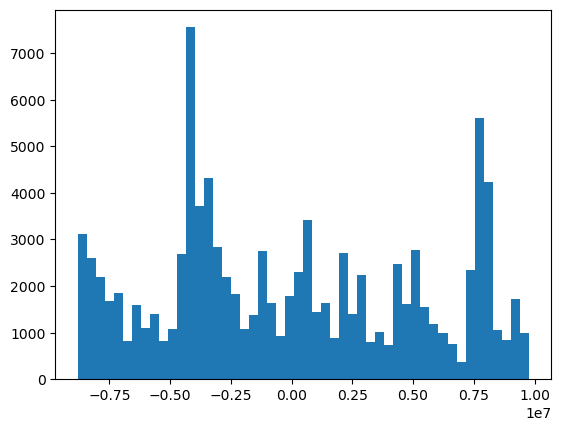

npos = 55375
nneg = 44625
np.max(uidx_train) = 942
np.max(uidx_ttest) = 942
np.max(iidx_train) = 1681
np.max(iidx_ttest) = 1680


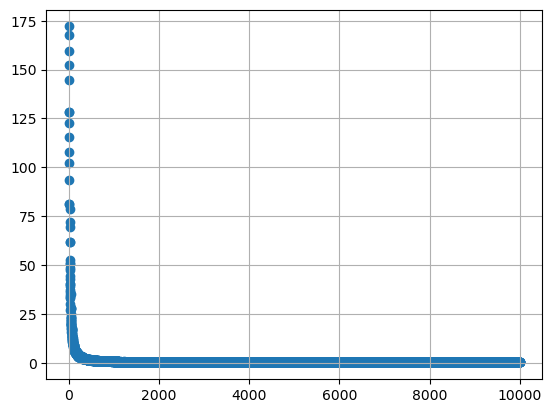

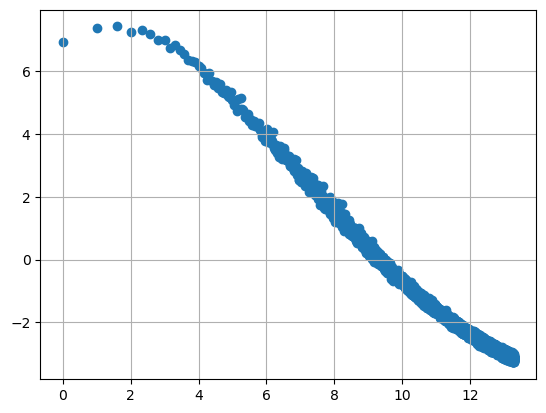

umat.shape = (943, 120)
imat.shape = (1682, 120)
roc_auc_train = 0.9449310836647007
roc_auc_ttest = 0.9439066281569817


0

In [3]:
def get_positives_and_negatives(idata, rtarget):
    nedge = idata.shape[0]
    emat = np.zeros(nedge)
    uidx = np.zeros((nedge), dtype=np.int64)
    iidx = np.zeros((nedge), dtype=np.int64)
    nneg = 0
    npos = 0

    for idx in range(idata.shape[0]):
        uidx[idx] = idata[idx, 0]
        iidx[idx] = idata[idx, 1]
        if idata[idx, 2] >= rtarget:
            npos += 1
            emat[idx] = 1.0
        else:
            nneg += 1
            emat[idx] = 0.0
    print('npos = ' + str(npos))
    print('nneg = ' + str(nneg))
    return (emat, uidx, iidx)

def train_test_split_old(emat, uidx, iidx, frac_train=0.7):

    nedge = emat.size
    ntrain = np.int64(frac_train * nedge)
    nttest = nedge - ntrain
    perm = np.random.permutation(nedge)
    idx_train = perm[:ntrain]
    idx_ttest = perm[ntrain:]
    ### what happens here?
    emat_train = emat[idx_train[:]]
    uidx_train = uidx[idx_train[:]]
    iidx_train = iidx[idx_train[:]]
    emat_ttest = emat[idx_ttest[:]]
    uidx_ttest = uidx[idx_ttest[:]]
    iidx_ttest = iidx[idx_ttest[:]]
    
    return (emat_train, uidx_train, iidx_train,
            emat_ttest, uidx_ttest, iidx_ttest)

def train_test_split(emat, uidx, iidx, timestemp_data, frac_train=0.7):
    t_threshold = np.quantile(timestemp_data, frac_train)
    nedge = emat.size
    emat_train = []
    uidx_train = []
    iidx_train = []
    emat_ttest = []
    uidx_ttest = []
    iidx_ttest = []
    for iedge in range(nedge):
        if timestemp_data[iedge] <= t_threshold:
            emat_train.append(emat[iedge])
            uidx_train.append(uidx[iedge])
            iidx_train.append(iidx[iedge])
        else:
            emat_ttest.append(emat[iedge])
            uidx_ttest.append(uidx[iedge])
            iidx_ttest.append(iidx[iedge])
    emat_train = np.asarray(emat_train, dtype=np.float64)
    uidx_train = np.asarray(uidx_train, dtype=np.int64)
    iidx_train = np.asarray(iidx_train, dtype=np.int64)

    emat_ttest = np.asarray(emat_ttest, dtype=np.float64)
    uidx_ttest = np.asarray(uidx_ttest, dtype=np.int64)
    iidx_ttest = np.asarray(iidx_ttest, dtype=np.int64)
    
    return (emat_train, uidx_train, iidx_train,
            emat_ttest, uidx_ttest, iidx_ttest)

def recom_svd_via_sgd():
    print('inside the main function')
    ratings = pd.read_csv('./ml-100k/u.data', sep='\t', names=['user_id', 'movie_id', 'rating', 'timestamp'])
    print(ratings.head())
    idata = ratings.values
    print(idata.shape)
    idata[:, 0] -= 1
    idata[:, 1] -= 1
    nuser = np.max(idata[:, 0]) + 1
    nitem = np.max(idata[:, 1]) + 1
    print(np.min(idata[:, 0]))
    print(np.max(idata[:, 0]))
    print(np.min(idata[:, 1]))
    print(np.max(idata[:, 1]))
    print(idata[:10, 2])
    print('nuser = ' + str(nuser))
    print('nitem = ' + str(nitem))
    print(np.min(idata[:, 2]))
    print(np.max(idata[:, 2]))

    idata[:, 3] = idata[:, 3] - np.mean(idata[:, 3])
    plt.figure()
    plt.hist(idata[:, 3], bins=50)
    plt.show()
    rtarget = 4.0
    emat, uidx, iidx = get_positives_and_negatives(idata, rtarget)
    emat_train, uidx_train, iidx_train, emat_ttest, uidx_ttest, iidx_ttest = train_test_split(emat, uidx, iidx, idata[:, 3], frac_train=0.7)
    nvec = 120
    print('np.max(uidx_train) = ' + str(np.max(uidx_train)))
    print('np.max(uidx_ttest) = ' + str(np.max(uidx_ttest)))
    print('np.max(iidx_train) = ' + str(np.max(iidx_train)))
    print('np.max(iidx_ttest) = ' + str(np.max(iidx_ttest)))
    # umat, imat = compute_eigen_data_sparse(emat_train, uidx_train, iidx_train, nitem, nuser, nvec, niter=10000)
    dt0 = 1000.0
    niter = 10000
    nbatch = 2048
    umat, imat, rdata = svd_via_sgd(emat, uidx, iidx, nuser, nitem, nvec, dt0, niter, nbatch)
    plt.figure()
    plt.scatter(np.linspace(1, rdata.size, rdata.size), rdata)
    plt.grid()
    plt.show()
    plt.figure()
    plt.scatter(np.log(np.linspace(1.0, rdata.size, rdata.size)) / np.log(2.0), np.log(rdata) / np.log(2.0))
    plt.grid()
    plt.show()
    print('umat.shape = ' + str(umat.shape))
    print('imat.shape = ' + str(imat.shape))
    score_train = np.sum(umat[uidx_train[:], :] * imat[iidx_train[:], :], axis=1)
    label_train = emat_train
    score_ttest = np.sum(umat[uidx_ttest[:], :] * imat[iidx_ttest[:], :], axis=1)
    label_ttest = emat_ttest
    
    roc_auc_train = roc_auc_score(label_train, score_train)
    roc_auc_ttest = roc_auc_score(label_ttest, score_ttest)
    print('roc_auc_train = ' + str(roc_auc_train))
    print('roc_auc_ttest = ' + str(roc_auc_ttest))
    return 0

recom_svd_via_sgd()

In [4]:
def generate_random_martrix(n0, n1):
    amat = np.random.normal(0.0, 1.0, (n0, n1))
    return amat

@jit(nopython=True, fastmath=True)
def convert_dense_to_sparse(amat):
    n0, n1 = amat.shape
    ### what is the next step
    smat = np.zeros((n0 * n1))
    iidx = np.zeros((n0 * n1), dtype=np.int64)
    jidx = np.zeros((n0 * n1), dtype=np.int64)
    idx_sparse = 0
    for idx0 in range(n0):
        for idx1 in range(n1):
            smat[idx_sparse] = amat[idx0, idx1]
            iidx[idx_sparse] = idx0
            jidx[idx_sparse] = idx1
            idx_sparse = idx_sparse + 1
    return (smat, iidx, jidx)

def eigen_vector_calculation_test():
    n0 = 60
    n1 = 30
    nvec = 30
    amat = generate_random_martrix(n0, n1)
    smat, iidx, jidx = convert_dense_to_sparse(amat)
    niter = 1000
    dt0 = 0.1
    nbatch = 512
    umat, imat = svd_via_sgd(smat, iidx, jidx, n0, n1, nvec, dt0, niter, nbatch)
    print('umat:')
    print(umat)
    print('imat:')
    print(imat)
    ### should you check that the inner product is the same
    pred = np.dot(umat, np.transpose(imat))
    res = np.max(np.absolute(pred - amat))
    print('res = ' + str(res))
    return 0
    
# eigen_vector_calculation_test()

$$
f(x) = \frac{1}{2} x^2
$$
$$
\nabla f = x
$$
$$
g = x + \zeta
$$

In [5]:
def noisy_grad(x, sigma=0.1):
    return x + sigma * np.random.normal(0.0, 1.0, x.shape)

def sgd_test():
    x0 = 1.0 
    dt0 = 2.0001
    niter = 1000
    xdata = np.zeros((niter + 1))
    tdata = np.zeros((niter + 1))
    xdata[0] = x0
    for kiter in range(niter):
        dt = 1.0 * dt0 / np.sqrt(1.0 + kiter)
        g = noisy_grad(xdata[kiter : (kiter + 1)], sigma=0.1)
        xdata[kiter + 1] = xdata[kiter] - g * dt
        tdata[kiter + 1] = tdata[kiter] + dt
    plt.figure()
    plt.scatter(tdata, xdata)
    plt.grid()
    plt.show()
    return 0

# sgd_test()

In [6]:
@jit(nopython=True, fastmath=True)
def gram_schmidt_orth(wdata, eps=1.0e-6):
    numw, dimw = wdata.shape
    udata = 0.0 + wdata
    for idx0 in range(numw):
        for idx1 in range(idx0):
            norm_sq = max(eps, np.dot(udata[idx1, :], udata[idx1, :]))
            udata[idx0, :] = udata[idx0, :] - np.dot(udata[idx1, :], udata[idx0, :]) / norm_sq * udata[idx1, :]        
        norm = max(eps, np.sqrt(np.dot(udata[idx0, :], udata[idx0, :])))
        udata[idx0, :] = udata[idx0, :] / norm
    return udata
    
def generate_diagonal(n):
    dval = np.exp(np.random.normal(0.0, 1.0, (n)))
    dval = -np.sort(-dval)
    dmat = np.zeros((n, n))
    for idx in range(n):
        dmat[idx, idx] = dval[idx]
    return dmat
    
def quick_power():
    n = 6
    niter = 10
    w = gram_schmidt_orth(np.random.normal(0.0, 1.0, (n, n)))
    dmat = generate_diagonal(n)
    print(dmat)
    for kiter in range(niter):
        w = gram_schmidt_orth(np.dot(0.0 + w, dmat))
        plt.figure()
        plt.imshow(np.absolute(w))
        plt.show()
    return 0

# quick_power()